# Hyperparameter Tuning and Error Analysis

This notebook performs a small, controlled search around the Step 010
multimodal model.

The test split remains untouched.

## Experimental rule

The search is deliberately limited to three configurations.

A large search would overfit the small validation set and make the
result look more reliable than it is.

In [1]:
from pathlib import Path
import sys
import tempfile

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset_builder import (
    build_development_dataset,
)
from src.multimodal_neural_network import (
    LABEL_ORDER,
    build_multimodal_neural_network,
    create_multimodal_dataset,
    create_text_vectorizer,
    decode_predictions,
    encode_labels,
)
from src.multimodal_tuning import (
    build_error_analysis_table,
    get_tuning_configurations,
    select_best_configuration,
    summarize_validation_errors,
)

keras.utils.set_random_seed(42)

In [2]:
processed_directory = (
    project_root
    / "data"
    / "processed"
)

train_data = pd.read_csv(
    processed_directory
    / "train_chart_claim_dataset.csv"
)

validation_data = pd.read_csv(
    processed_directory
    / "validation_chart_claim_dataset.csv"
)

print("Training rows:", len(train_data))
print(
    "Validation rows:",
    len(validation_data),
)

print(
    "Validation groups:",
    validation_data[
        "chart_group_id"
    ].nunique(),
)

Training rows: 252
Validation rows: 54
Validation groups: 1


## Recreate ignored chart images when needed

In [3]:
first_image_path = (
    project_root
    / train_data["image_path"].iloc[0]
)

if not first_image_path.exists():
    source_data = pd.read_csv(
        processed_directory
        / "eu_unemployment_2019_2025.csv"
    )

    build_development_dataset(
        data=source_data,
        output_directory=(
            project_root
            / "data"
            / "generated"
            / "charts"
            / "development"
        ),
    )

print(
    "First image exists:",
    first_image_path.exists(),
)

First image exists: True


In [4]:
train_text = (
    train_data["claim_text"]
    .astype(str)
    .to_numpy()
)

validation_text = (
    validation_data["claim_text"]
    .astype(str)
    .to_numpy()
)

train_labels = encode_labels(
    train_data["label"]
)

validation_labels = encode_labels(
    validation_data["label"]
)

train_image_paths = [
    str(project_root / relative_path)
    for relative_path
    in train_data["image_path"]
]

validation_image_paths = [
    str(project_root / relative_path)
    for relative_path
    in validation_data["image_path"]
]

## Controlled search configurations

In [5]:
tuning_configurations = (
    get_tuning_configurations()
)

pd.DataFrame(
    tuning_configurations
)

,config_name,embedding_dimension,text_units,combined_units,dropout_rate,learning_rate
0,baseline,32,32,64,0.30,0.0010
1,lower_dropout,32,32,64,0.15,0.0010
2,wider_fusion,48,48,96,0.30,0.0007


## Train and compare

Each configuration uses the same training and validation rows, random
seed, early-stopping rule and maximum epoch count.

In [6]:
tuning_rows = []
history_tables = []

with tempfile.TemporaryDirectory() as temporary_directory:
    temporary_path = Path(
        temporary_directory
    )

    for configuration in tuning_configurations:
        keras.backend.clear_session()
        keras.utils.set_random_seed(42)

        vectorizer = create_text_vectorizer(
            training_text=train_text,
            max_tokens=1000,
            sequence_length=24,
        )

        train_dataset = (
            create_multimodal_dataset(
                image_paths=(
                    train_image_paths
                ),
                claim_texts=train_text,
                labels=train_labels,
                image_size=96,
                batch_size=16,
                shuffle=True,
                random_state=42,
            )
        )

        validation_dataset = (
            create_multimodal_dataset(
                image_paths=(
                    validation_image_paths
                ),
                claim_texts=(
                    validation_text
                ),
                labels=validation_labels,
                image_size=96,
                batch_size=16,
                shuffle=False,
            )
        )

        model = (
            build_multimodal_neural_network(
                vectorizer=vectorizer,
                image_size=96,
                embedding_dimension=(
                    configuration[
                        "embedding_dimension"
                    ]
                ),
                text_units=(
                    configuration[
                        "text_units"
                    ]
                ),
                combined_units=(
                    configuration[
                        "combined_units"
                    ]
                ),
                dropout_rate=(
                    configuration[
                        "dropout_rate"
                    ]
                ),
                learning_rate=(
                    configuration[
                        "learning_rate"
                    ]
                ),
            )
        )

        early_stopping = (
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=4,
                restore_best_weights=True,
            )
        )

        history = model.fit(
            train_dataset,
            validation_data=(
                validation_dataset
            ),
            epochs=20,
            callbacks=[early_stopping],
            verbose=0,
        )

        probabilities = model.predict(
            validation_dataset,
            verbose=0,
        )

        prediction_indices = np.argmax(
            probabilities,
            axis=1,
        )

        predictions = decode_predictions(
            prediction_indices
        )

        accuracy = accuracy_score(
            validation_data["label"],
            predictions,
        )

        macro_f1 = f1_score(
            validation_data["label"],
            predictions,
            average="macro",
            zero_division=0,
        )

        epochs_completed = len(
            history.history["loss"]
        )

        tuning_rows.append(
            {
                **configuration,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
                "epochs_completed": (
                    epochs_completed
                ),
                "evaluation_split": (
                    "validation"
                ),
            }
        )

        configuration_history = (
            pd.DataFrame(
                history.history
            )
        )

        configuration_history.index = (
            configuration_history.index
            + 1
        )

        configuration_history.index.name = (
            "epoch"
        )

        configuration_history = (
            configuration_history
            .reset_index()
        )

        configuration_history.insert(
            0,
            "config_name",
            configuration[
                "config_name"
            ],
        )

        history_tables.append(
            configuration_history
        )

        candidate_path = (
            temporary_path
            / (
                configuration[
                    "config_name"
                ]
                + ".keras"
            )
        )

        model.save(candidate_path)

        print(
            configuration[
                "config_name"
            ],
            "accuracy=",
            round(accuracy, 4),
            "macro_f1=",
            round(macro_f1, 4),
            "epochs=",
            epochs_completed,
        )

    tuning_results = pd.DataFrame(
        tuning_rows
    )

    tuning_history = pd.concat(
        history_tables,
        ignore_index=True,
    )

    best_result = (
        select_best_configuration(
            tuning_results
        )
    )

    best_config_name = str(
        best_result["config_name"]
    )

    best_model = keras.models.load_model(
        temporary_path
        / f"{best_config_name}.keras"
    )

    final_validation_dataset = (
        create_multimodal_dataset(
            image_paths=(
                validation_image_paths
            ),
            claim_texts=validation_text,
            labels=validation_labels,
            image_size=96,
            batch_size=16,
            shuffle=False,
        )
    )

    best_probabilities = (
        best_model.predict(
            final_validation_dataset,
            verbose=0,
        )
    )

    models_directory = (
        project_root / "models"
    )

    models_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    best_model.save(
        models_directory
        / (
            "tuned_multimodal_"
            "neural_network.keras"
        )
    )

tuning_results.sort_values(
    by=[
        "macro_f1",
        "accuracy",
    ],
    ascending=False,
)

C:\Users\stana\Desktop\chart-claim-verification-bg\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


baseline accuracy= 0.8889 macro_f1= 0.8885 epochs= 20


C:\Users\stana\Desktop\chart-claim-verification-bg\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


lower_dropout accuracy= 0.8889 macro_f1= 0.8885 epochs= 20


C:\Users\stana\Desktop\chart-claim-verification-bg\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


wider_fusion accuracy= 0.8333 macro_f1= 0.8279 epochs= 20


,config_name,embedding_dimension,text_units,combined_units,dropout_rate,learning_rate,accuracy,macro_f1,epochs_completed,evaluation_split
0,baseline,32,32,64,0.30,0.0010,0.888889,0.888500,20,validation
1,lower_dropout,32,32,64,0.15,0.0010,0.888889,0.888500,20,validation
2,wider_fusion,48,48,96,0.30,0.0007,0.833333,0.827894,20,validation


## Selected configuration

In [7]:
best_result.to_frame(
    name="selected_value"
)

,selected_value
config_name,baseline
embedding_dimension,32
text_units,32
combined_units,64
dropout_rate,0.3
learning_rate,0.001
accuracy,0.888889
macro_f1,0.8885
epochs_completed,20
evaluation_split,validation


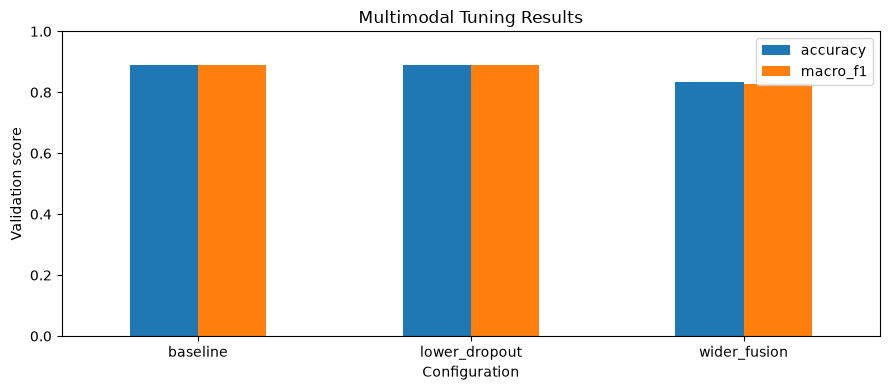

In [8]:
metric_view = (
    tuning_results.set_index(
        "config_name"
    )[
        [
            "accuracy",
            "macro_f1",
        ]
    ]
)

metric_view.plot(
    kind="bar",
    figsize=(9, 4),
)

plt.title(
    "Multimodal Tuning Results"
)
plt.xlabel("Configuration")
plt.ylabel("Validation score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Error analysis for the selected model

In [9]:
best_prediction_indices = np.argmax(
    best_probabilities,
    axis=1,
)

best_predictions = decode_predictions(
    best_prediction_indices
)

error_analysis = (
    build_error_analysis_table(
        validation_data=validation_data,
        predicted_labels=(
            best_predictions
        ),
        predicted_probabilities=(
            best_probabilities
        ),
        label_order=LABEL_ORDER,
    )
)

validation_errors = (
    error_analysis.loc[
        ~error_analysis["correct"]
    ]
    .sort_values(
        by="confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

error_summary = (
    summarize_validation_errors(
        error_analysis
    )
)

print(
    "Correct predictions:",
    int(error_analysis["correct"].sum()),
)

print(
    "Validation errors:",
    len(validation_errors),
)

validation_errors[
    [
        "chart_group_id",
        "claim_text",
        "true_label",
        "predicted_label",
        "confidence",
        "error_type",
    ]
]

Correct predictions: 48
Validation errors: 6


,chart_group_id,claim_text,true_label,predicted_label,confidence,error_type
0,window_2019_2025,The EU unemployment rate was higher in 2025 th...,supported,not_enough_information,0.904147,supported -> not_enough_information
1,window_2019_2025,The EU unemployment rate was higher in 2025 th...,supported,not_enough_information,0.904104,supported -> not_enough_information
2,window_2019_2025,The EU unemployment rate was higher in 2025 th...,supported,not_enough_information,0.904077,supported -> not_enough_information
3,window_2019_2025,The EU unemployment rate was lower in 2020 tha...,refuted,supported,0.897048,refuted -> supported
4,window_2019_2025,The EU unemployment rate was lower in 2020 tha...,refuted,supported,0.896939,refuted -> supported
5,window_2019_2025,The EU unemployment rate was lower in 2020 tha...,refuted,supported,0.896818,refuted -> supported


In [10]:
error_summary

,true_label,predicted_label,error_count
0,refuted,supported,3
1,supported,not_enough_information,3


## Final validation metrics for the selected configuration

In [11]:
best_accuracy = accuracy_score(
    validation_data["label"],
    best_predictions,
)

best_macro_f1 = f1_score(
    validation_data["label"],
    best_predictions,
    average="macro",
    zero_division=0,
)

best_metrics = pd.DataFrame(
    [
        {
            "model": (
                "Tuned Keras multimodal "
                "neural network"
            ),
            "config_name": (
                best_config_name
            ),
            "accuracy": best_accuracy,
            "macro_f1": best_macro_f1,
            "evaluation_split": (
                "validation"
            ),
        }
    ]
)

best_metrics

,model,config_name,accuracy,macro_f1,evaluation_split
0,Tuned Keras multimodal neural network,baseline,0.888889,0.8885,validation


In [12]:
best_report = pd.DataFrame(
    classification_report(
        validation_data["label"],
        best_predictions,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )
).transpose()

best_report

,precision,recall,f1-score,support
supported,0.833333,0.833333,0.833333,18.000000
refuted,1.000000,0.833333,0.909091,18.000000
not_enough_information,0.857143,1.000000,0.923077,18.000000
accuracy,0.888889,0.888889,0.888889,0.888889
macro avg,0.896825,0.888889,0.888500,54.000000
weighted avg,0.896825,0.888889,0.888500,54.000000


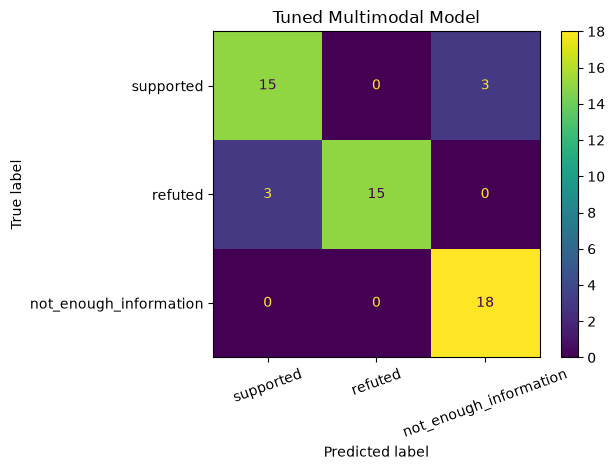

In [13]:
best_matrix = confusion_matrix(
    validation_data["label"],
    best_predictions,
    labels=LABEL_ORDER,
)

ConfusionMatrixDisplay(
    confusion_matrix=best_matrix,
    display_labels=LABEL_ORDER,
).plot(
    xticks_rotation=20,
)

plt.title(
    "Tuned Multimodal Model"
)
plt.tight_layout()
plt.show()

## Update the validation comparison

In [14]:
comparison_path = (
    project_root
    / "reports"
    / "model_validation_comparison.csv"
)

model_comparison = pd.read_csv(
    comparison_path
)

model_comparison = (
    model_comparison.loc[
        model_comparison["model"]
        != (
            "Tuned Keras multimodal "
            "neural network"
        )
    ]
)

comparison_row = best_metrics[
    [
        "model",
        "accuracy",
        "macro_f1",
        "evaluation_split",
    ]
]

model_comparison = pd.concat(
    [
        model_comparison,
        comparison_row,
    ],
    ignore_index=True,
)

model_comparison

,model,accuracy,macro_f1,evaluation_split
0,Majority baseline,0.333333,0.166667,validation
1,TF-IDF + Logistic Regression,0.777778,0.772339,validation
2,Keras text neural network,0.833333,0.827894,validation
3,Keras CNN image model,0.333333,0.166667,validation
4,Keras multimodal neural network,0.888889,0.888500,validation
5,Tuned Keras multimodal neural network,0.888889,0.888500,validation


## Save tuning and error reports

In [15]:
reports_directory = (
    project_root / "reports"
)

reports_directory.mkdir(
    parents=True,
    exist_ok=True,
)

tuning_results.to_csv(
    reports_directory
    / "multimodal_tuning_results.csv",
    index=False,
)

tuning_history.to_csv(
    reports_directory
    / "multimodal_tuning_history.csv",
    index=False,
)

best_metrics.to_csv(
    reports_directory
    / (
        "multimodal_best_"
        "validation_metrics.csv"
    ),
    index=False,
)

best_report.to_csv(
    reports_directory
    / (
        "multimodal_best_"
        "validation_report.csv"
    )
)

pd.DataFrame(
    best_matrix,
    index=[
        f"actual_{label}"
        for label in LABEL_ORDER
    ],
    columns=[
        f"predicted_{label}"
        for label in LABEL_ORDER
    ],
).to_csv(
    reports_directory
    / (
        "multimodal_best_"
        "validation_confusion_matrix.csv"
    )
)

error_analysis.to_csv(
    reports_directory
    / (
        "multimodal_validation_"
        "predictions.csv"
    ),
    index=False,
)

validation_errors.to_csv(
    reports_directory
    / (
        "multimodal_validation_"
        "errors.csv"
    ),
    index=False,
)

error_summary.to_csv(
    reports_directory
    / (
        "multimodal_error_"
        "summary.csv"
    ),
    index=False,
)

model_comparison.to_csv(
    comparison_path,
    index=False,
)

print(
    "Tuning and error reports saved."
)

Tuning and error reports saved.


## Honest conclusion

The selected configuration is the best of a small validation search.

Because the validation split guided model selection, its score may be
optimistic. The untouched test split is reserved for the final
evaluation after model development is complete.